##### Ссылка на репозиторий и этот ноутбук с файлами: github: https://github.com/randnull/genotec/blob/main/hw_6_f_score.ipynb

Домашнее задание 6

Прочитаем данные о популяции

In [19]:
library(admixtools)
library(tidyverse)

prefix <- "Southern_Levant_Data/SouthLevantBA"
pops_mini <- c("Megiddo_MLBA", "Baqah", "Yehud")
pops <- c("Megiddo_MLBA", "Baqah", "Yehud", "Hazor")
f2_dir <- "results/f2_southlevant"


прочитаем данные о f2-блоках

сделаем отдельно на 3 и на 4 популяции (для f2, f3 и для f4)

In [21]:
extract_f2(prefix, f2_dir, pops=pops, maxmiss=0.5, overwrite=TRUE)

f2_mini <- f2_from_precomp(f2_dir, pops=pops_mini)
f2_full <- f2_from_precomp(f2_dir, pops=pops)

dim(f2_mini)
dim(f2_full)

ℹ Reading allele frequencies from EIGENSTRAT files...


ℹ Reading part 1 of 100...
ℹ Reading part 2 of 100...
ℹ Reading part 3 of 100...
ℹ Reading part 4 of 100...
ℹ Reading part 5 of 100...
ℹ Reading part 6 of 100...
ℹ Reading part 7 of 100...
ℹ Reading part 8 of 100...
ℹ Reading part 9 of 100...
ℹ Reading part 10 of 100...
ℹ Reading part 11 of 100...
ℹ Reading part 12 of 100...
ℹ Reading part 13 of 100...
ℹ Reading part 14 of 100...
ℹ Reading part 15 of 100...
ℹ Reading part 16 of 100...
ℹ Reading part 17 of 100...
ℹ Reading part 18 of 100...
ℹ Reading part 19 of 100...
ℹ Reading part 20 of 100...
ℹ Reading part 21 of 100...
ℹ Reading part 22 of 100...
ℹ Reading part 23 of 100...
ℹ Reading part 24 of 100...
ℹ Reading part 25 of 100...
ℹ Reading part 26 of 100...
ℹ Reading part 27 of 100...
ℹ Reading part 28 of 100...
ℹ Reading part 29 of 100...
ℹ Reading part 30 of 100...
ℹ Reading part 31 of 100...
ℹ Reading part 32 of 100...
ℹ Reading part 33 of 100...
ℹ Reading part 34 of 100...
ℹ Reading part 35 of 100...
ℹ Reading part 36 of 100...
ℹ

ℹ SouthLevantBA.geno has 73 samples and 1233013 SNPs
ℹ Calculating allele frequencies from 47 samples in 4 populations


Warning message in discard_snps(snpdat, maxmiss = maxmiss, auto_only = auto_only, :
“Keeping only chromosomes 1 to 22! Set `auto_only = FALSE` to keep all chromosomes!”


! 1025387 SNPs remain after filtering. 737698 are polymorphic.
ℹ Allele frequency matrix for 1025387 SNPs and 4 populations is 107 MB
ℹ Computing pairwise f2 for all SNPs and population pairs requires 853 MB RAM without splitting
ℹ Computing without splitting since 853 < 8000 (maxmem)...
ℹ Data written to results/f2_southlevant/
ℹ Reading precomputed data for 3 populations...


ℹ Reading f2 data for 6 pairs...
Warning message in read_f2(dir, pops, pops2, type = type, remove_na = remove_na, :
“Discarding 1 block(s) due to missing values!
Discarded block(s): 538”


ℹ Reading precomputed data for 4 populations...


ℹ Reading f2 data for 10 pairs...
Warning message in read_f2(dir, pops, pops2, type = type, remove_na = remove_na, :
“Discarding 1 block(s) due to missing values!
Discarded block(s): 538”


[1]   3   3 712

[1]   4   4 712

Получаем 3 x 3 x 712 блоков и 4 х 4 х 712


Получается, что 3 х 3 и 4 х 4 - это попарные f2

Первое это f2. 

f2 у нас смотрит, насколько разошлись две популяции, которые мы сравниваем

In [22]:
f2(f2_mini)

pop1,pop2,est,se
<chr>,<chr>,<dbl>,<dbl>
Baqah,Yehud,0.14799838,0.0005970754
Megiddo_MLBA,Baqah,0.02363019,0.0003480492
Megiddo_MLBA,Yehud,0.15294926,0.0006629759


Видно, что Megiddo_MLBA	и Baqah достаточно близки друг в другу

Посчитаем f3.

Тут первым идет то, кого мы пытается детектить, а остальные это источники примеси.

Будет смотреть на положительность коэфа - если f3 > 0 = первый это потомок общего предка двух остальных, а иначе - смесь из них

In [25]:
rbind(
  f3(f2_mini, "Yehud", "Megiddo_MLBA", "Baqah"),
  f3(f2_mini, "Megiddo_MLBA", "Baqah", "Yehud"),
  f3(f2_mini, "Baqah", "Megiddo_MLBA", "Yehud")
)

pop1,pop2,pop3,est,se,z,p
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Yehud,Megiddo_MLBA,Baqah,0.138658724,0.0005721212,242.35901,0.000000e+00
Megiddo_MLBA,Baqah,Yehud,0.014290536,0.0003241863,44.08125,0.000000e+00
Baqah,Megiddo_MLBA,Yehud,0.009339659,0.0002813040,33.20130,1.031049e-241


Видно, что все значения > 0 => никто не образовался как смесь других.

И последнее - f4 (тут проверяем, pop1 + pop2 одна ветка, а остальные - другая?):

In [26]:
f4(f2_full)

pop1,pop2,pop3,pop4,est,se,z,p
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Megiddo_MLBA,Baqah,Yehud,Hazor,0.000131155,0.0002893766,0.4532329,6.503810e-01
Megiddo_MLBA,Yehud,Baqah,Hazor,0.004378130,0.0004280297,10.2285655,1.476908e-24
Megiddo_MLBA,Hazor,Baqah,Yehud,0.004246975,0.0004433047,9.5802625,9.679856e-22


По Z видно, что Megiddo_MLBA и Baqah на одной ветке, а Yehud и Hazor на другой

Также можем посмотреть на дерево популяций:

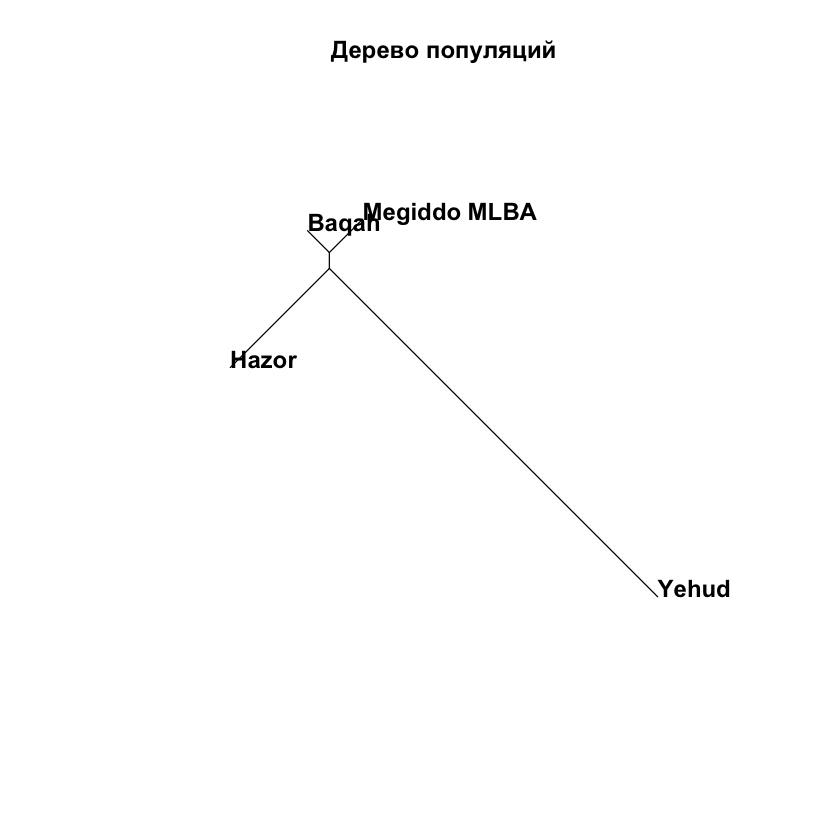

In [28]:
library(ape)
f2_mat <- apply(f2_full, c(1, 2), mean)
tree <- nj(as.dist(f2_mat))
plot(tree, type = "unrooted", cex = 1.2, font = 2)
title("Дерево популяций")

Видно, что Megiddo_MLBA	и Baqah близки друг в другу

также видно, что по веткам такое же деление, как и в f4